# Homework 3: Machine Learning for Classification

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [1]:
import requests

url = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'
r = requests.get(url)

with open('course_lead_scoring.csv', 'wb') as f:
    f.write(r.content)


In [3]:
df  = pd.read_csv('course_lead_scoring.csv')
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


## Data preparation

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1462 non-null   object 
 1   industry                  1462 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1462 non-null   float64
 4   employment_status         1462 non-null   object 
 5   location                  1462 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB




Replace categorial featuras with 'NA'

In [4]:
top_categorial = 'NA'

categorical_cols = ['lead_source', 'industry', 'employment_status', 'location']

for col in categorical_cols:
    df[col] = df[col].fillna(top_categorial)

Replace numerical featuras with 0.0

In [5]:
top_numerical = 0.0

df['annual_income'] = df['annual_income'].fillna(top_numerical)

In [6]:
null_per_cols = df.isnull().sum()
print(null_per_cols)

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64


## Q1

In [ ]:
freq = df['industry'].value_counts()
print(freq)

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NA               134
Name: count, dtype: int64


## Q2

In [7]:
numerical_cols = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numerical_cols.corr()
print(corr_matrix)

                          number_of_courses_viewed  annual_income  \
number_of_courses_viewed                  1.000000       0.009770   
annual_income                             0.009770       1.000000   
interaction_count                        -0.023565       0.027036   
lead_score                               -0.004879       0.015610   
converted                                 0.435914       0.053131   

                          interaction_count  lead_score  converted  
number_of_courses_viewed          -0.023565   -0.004879   0.435914  
annual_income                      0.027036    0.015610   0.053131  
interaction_count                  1.000000    0.009888   0.374573  
lead_score                         0.009888    1.000000   0.193673  
converted                          0.374573    0.193673   1.000000  


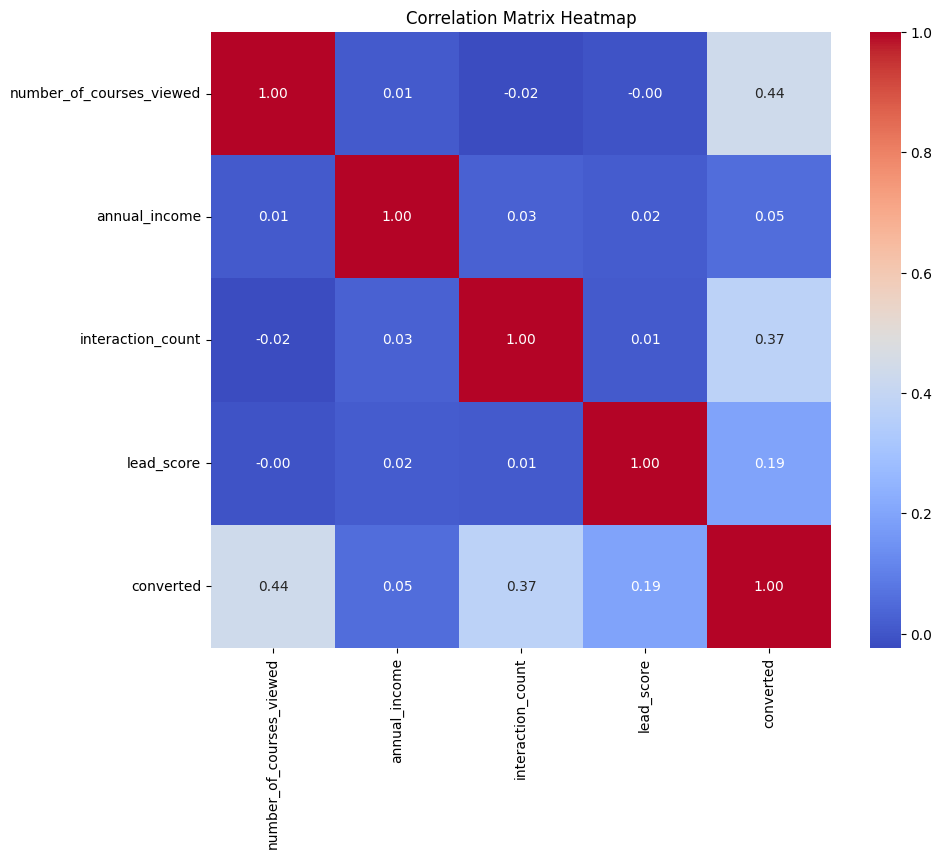

In [ ]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()


## Split the data

In [12]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

X = df.drop('converted', axis=1)
y = df['converted']


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Val: {len(X_val)} ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")



Train: 877 (60.0%)
Val: 292 (20.0%)
Test: 293 (20.0%)


## Q3

In [13]:
from sklearn.metrics import mutual_info_score

def mutual_info_converted_score(series):
    return mutual_info_score(series, df_train.converted)

categorical = df_train.select_dtypes(include=['object', 'category']).columns.drop('converted', errors='ignore')

mi = df_train[categorical].apply(mutual_info_converted_score)

mi = mi.round(2)

mi = mi.sort_values(ascending=False)

print(mi)


lead_source          0.02
employment_status    0.02
industry             0.01
location             0.00
dtype: float64


## Q4

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values

categorical = df_train.select_dtypes(include=['object', 'category']).columns

X_train = pd.get_dummies(df_train.drop('converted', axis=1), drop_first=True)
X_val = pd.get_dummies(df_val.drop('converted', axis=1), drop_first=True)

X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
acc = accuracy_score(y_val, y_pred)

print(f"Validation Accuracy: {round(acc, 2)}")


Validation Accuracy: 0.7


# Q5

In [16]:
# One-hot encoding
X_train = pd.get_dummies(df_train.drop('converted', axis=1), drop_first=True)
X_val = pd.get_dummies(df_val.drop('converted', axis=1), drop_first=True)

X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

y_train = df_train.converted.values
y_val = df_val.converted.values

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
base_acc = accuracy_score(y_val, y_pred)
print(f"Original validation accuracy: {base_acc:.4f}\n")

diffs = {}

for col in X_train.columns:
    X_train_sub = X_train.drop(columns=[col])
    X_val_sub = X_val.drop(columns=[col])

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model.fit(X_train_sub, y_train)

    y_pred_sub = model.predict(X_val_sub)
    acc_sub = accuracy_score(y_val, y_pred_sub)


    diffs[col] = base_acc - acc_sub

df_diffs = pd.DataFrame.from_dict(diffs, orient='index', columns=['accuracy_diff'])
df_diffs = df_diffs.sort_values(by='accuracy_diff', ascending=False)

print(df_diffs)


Original validation accuracy: 0.6997

                                 accuracy_diff
number_of_courses_viewed              0.116041
interaction_count                     0.112628
lead_source_referral                  0.003413
employment_status_unemployed          0.003413
employment_status_employed            0.003413
lead_source_social_media              0.000000
lead_score                            0.000000
industry_technology                   0.000000
employment_status_student             0.000000
industry_education                    0.000000
location_europe                       0.000000
employment_status_self_employed      -0.003413
industry_manufacturing               -0.003413
lead_source_organic_search           -0.003413
industry_finance                     -0.003413
lead_source_events                   -0.003413
industry_other                       -0.003413
industry_retail                      -0.003413
industry_healthcare                  -0.003413
location_australia    

# Q6

In [18]:
X_train = pd.get_dummies(df_train.drop('converted', axis=1), drop_first=True)
X_val = pd.get_dummies(df_val.drop('converted', axis=1), drop_first=True)

X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

y_train = df_train.converted.values
y_val = df_val.converted.values

C_values = [0.01, 0.1, 1, 10, 100]

accuracies = {}

for C in C_values:
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    accuracies[C] = round(acc, 3)

print("Validation accuracies by C value:")
for C, acc in accuracies.items():
    print(f"C={C}: accuracy={acc}")

best_C = max(accuracies, key=accuracies.get)
print(f"\nBest C: {best_C} (accuracy={accuracies[best_C]})")


Validation accuracies by C value:
C=0.01: accuracy=0.7
C=0.1: accuracy=0.7
C=1: accuracy=0.7
C=10: accuracy=0.7
C=100: accuracy=0.7

Best C: 0.01 (accuracy=0.7)
